# Characterize a backend

This notebook shows how to easily run a set of characterization experiments to get an updated backend reflecting real-time device properties (readout error, 1Q errors, 2Q errors, T1, T2). The main idea is to return a backend that shows real-time device properties, as opposed to relying on the properties reported on Qiskit.

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService, Session
from qiskit_device_benchmarking.utilities.characterization_utils import characterize_backend, plot_characterization_comparison

## Select backend

In [ ]:
service = QiskitRuntimeService()
device = 'ibm_pittsburgh'
backend = service.backend(device)

management.get:WARNING:2026-02-26 12:54:58,038: Loading default saved account


## Specify and run characterization experiments

Choose either of the options shown below to run the characterization experiments and update the backend object. This can be done either outside or inside of a session. One can choose to run any experiment in the following subset: 
- readout: SPAM (state preparation and measurement) experiment
- rb_1q: Isolated 1Q RB
- rb_2q: Simultaneous 2Q RB from a layer fidelity experiment
- t1: T1 experiment
- t2: T2 Hahn experiment

In [ ]:
# Run characterization experiments outside of a session
experiments = ['readout', 'rb_1q', 'rb_2q', 't1', 't2']
backend_updated = characterize_backend(backend=backend, experiments=experiments)

In [7]:
# Run characterization experiments inside of a session
experiments = ['readout', 'rb_1q', 'rb_2q', 't1', 't2']
with Session(backend=backend) as session:
    backend_updated = characterize_backend(backend=backend, experiments=experiments)

base_primitive._get_mode_service_backend:WARNING:2026-02-26 11:16:54,175: A backend was passed in as the mode but a session context manager is open so this job will run inside this session/batch instead of in job mode.


Readout job submitted: job_id = d6g73u0j9bds73cns27g
Single-qubit RB submitted: job ids = ['d6g77b8ddp9c73cf7nl0', 'd6g78ci24kpc73emhmtg']
Layered two-qubit RB submitted: job_ids = ['d6g7aeq24kpc73emhpfg', 'd6g7b2gj9bds73cnsb6g', 'd6g7cvgj9bds73cnsdi0', 'd6g7dkukeflc73ah3h6g']
T1 submitted: job ids = ['d6g7dm224kpc73emht0g']
T2 (Hahn) submitted: job ids = ['d6g7dn0ddp9c73cf7um0']
Updated backend properties: readout, single-qubit errors, two-qubit errors, T1, T2


## Plot characterization results

Finally, one can optionally plot a comparison between the reported backend properties on Qiskit and the measured real-time properties.

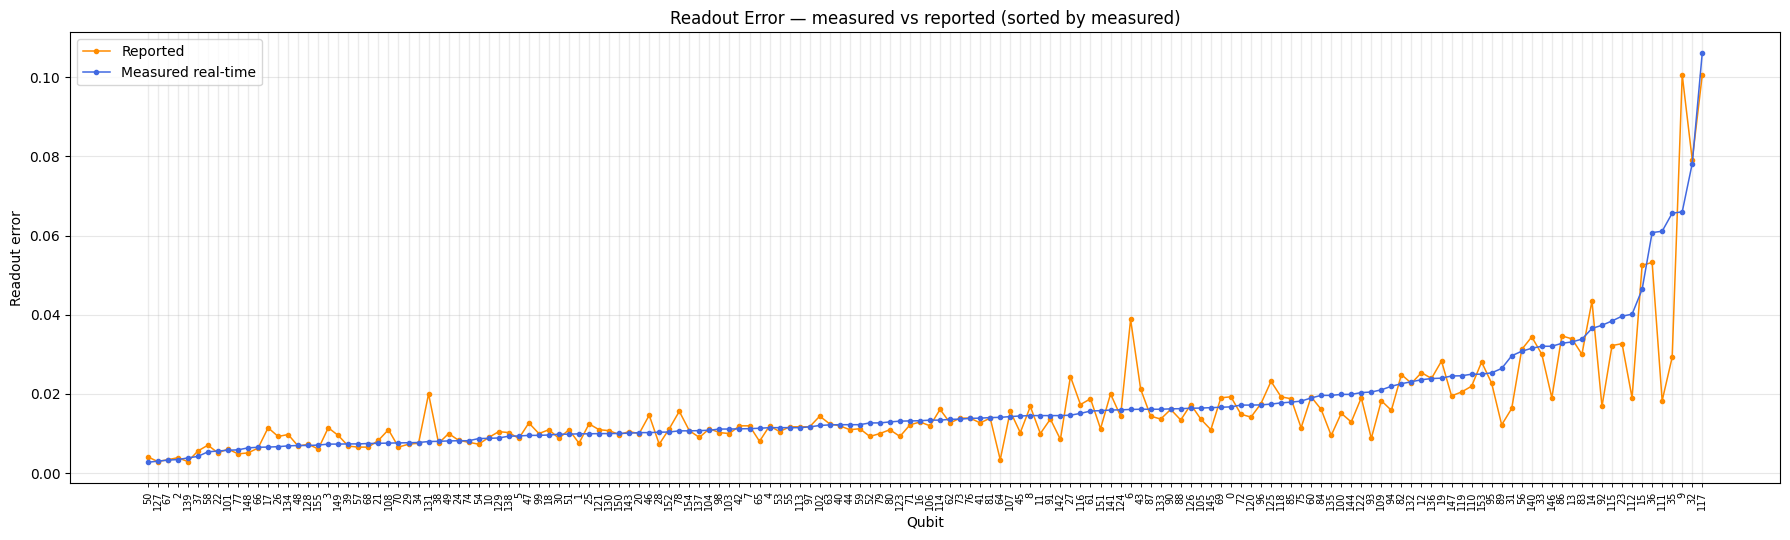

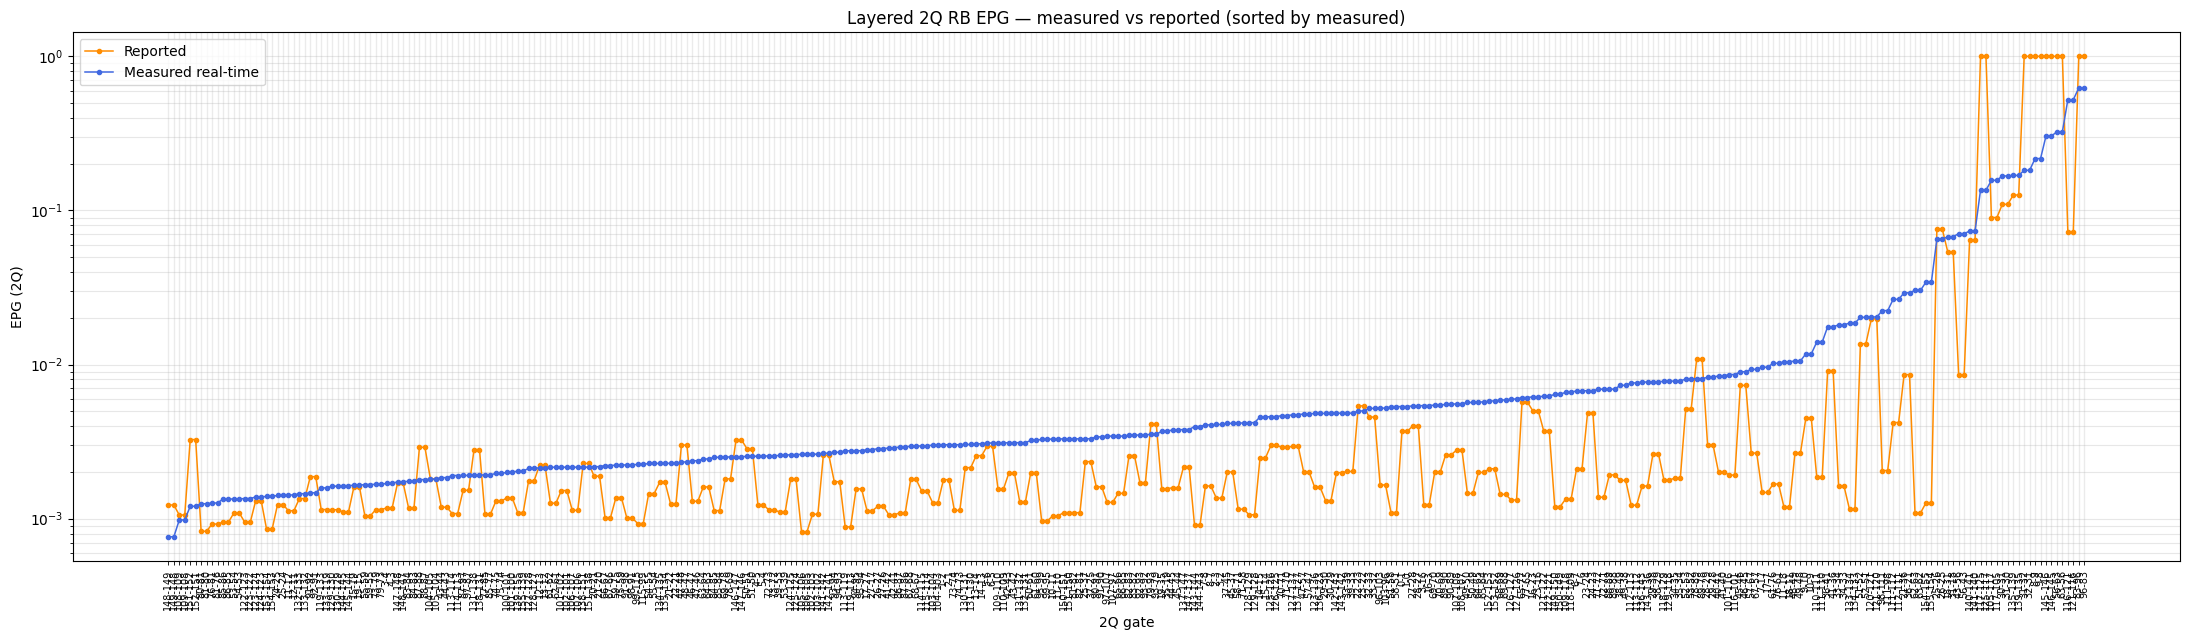

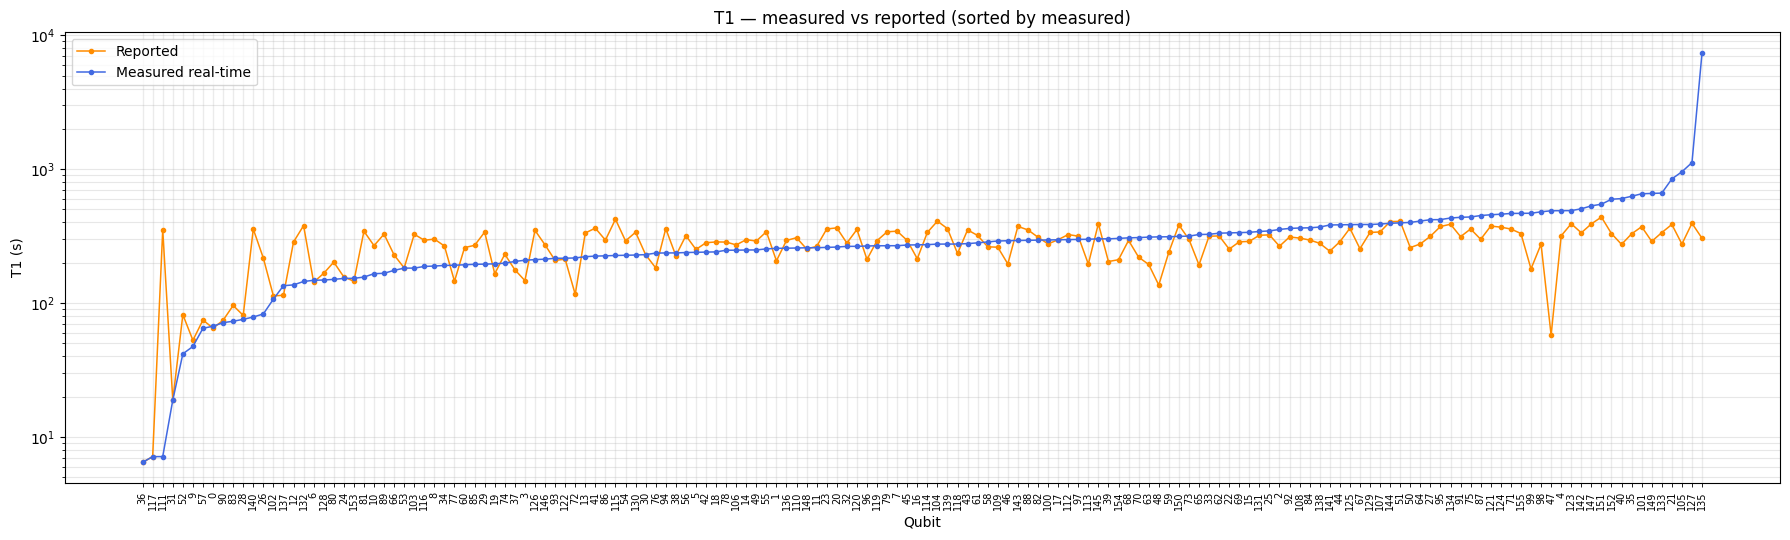

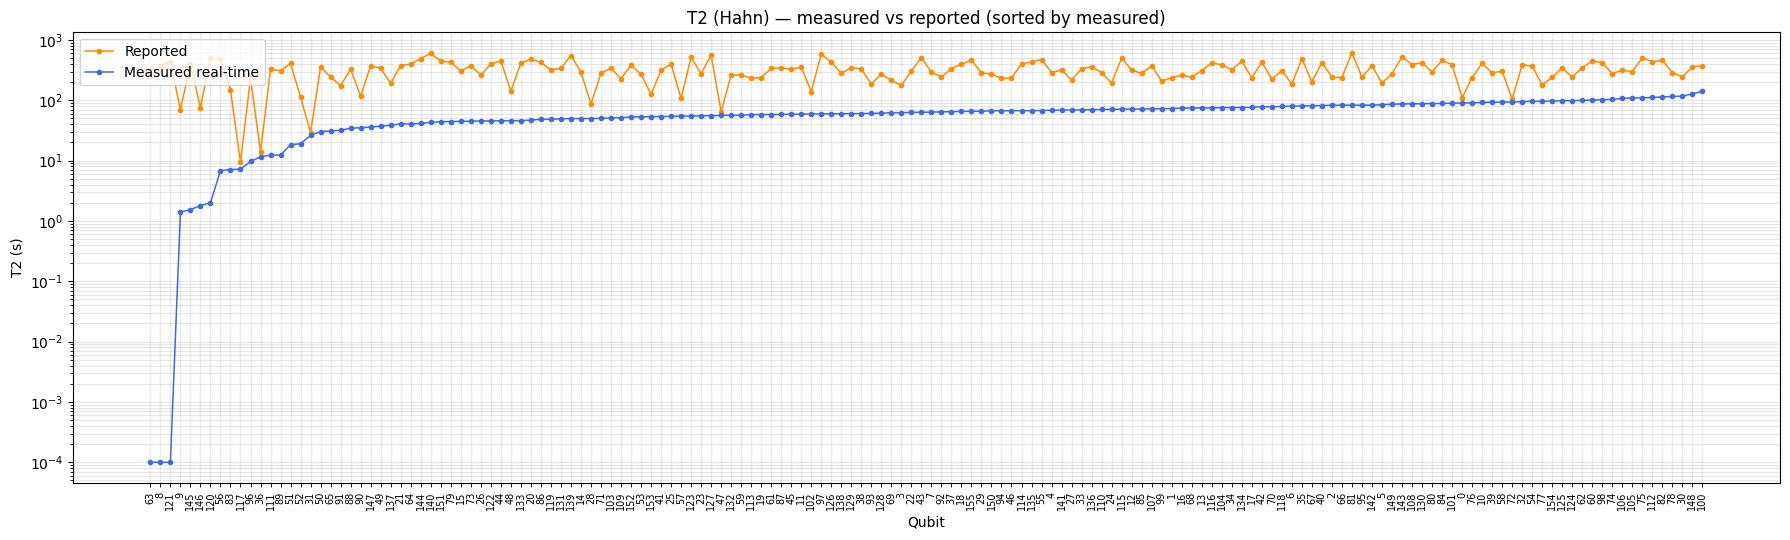

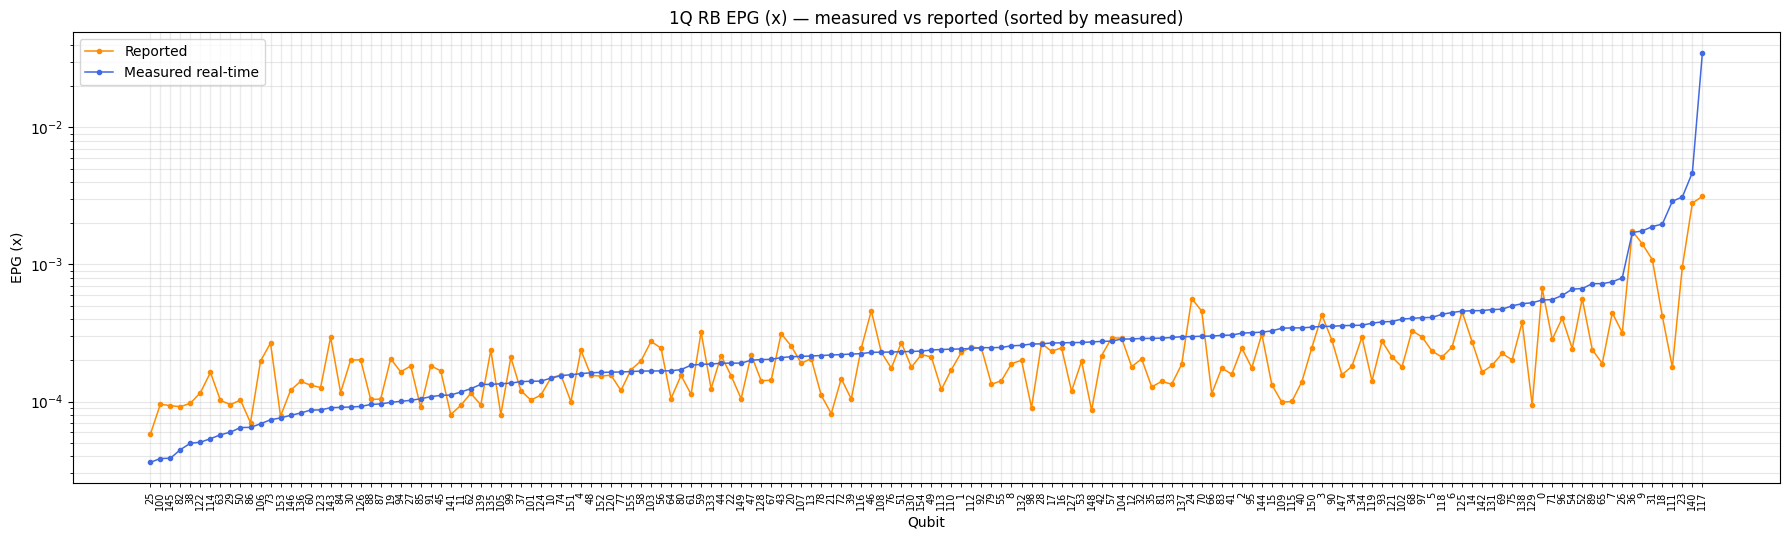

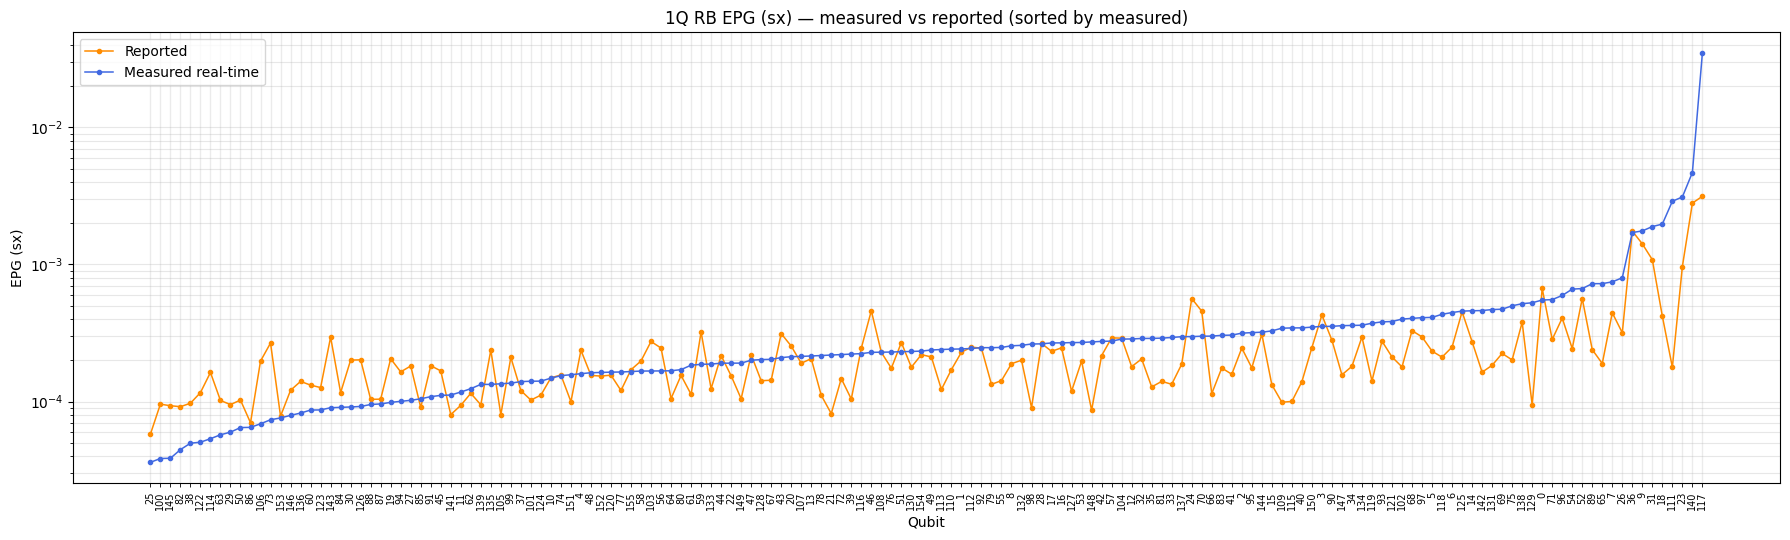

In [ ]:
plot_characterization_comparison(
    old_props=backend.properties().to_dict(),
    new_props=backend_updated.properties().to_dict(),
    plots = ['readout', 'rb_1q', 'rb_2q', 't1', 't2'],
)

In [6]:
import datetime
from IPython.display import HTML, display


def qiskit_copyright(line="", cell=None):
    """IBM copyright"""
    now = datetime.datetime.now()

    html = "<div style='width: 100%; background-color:#d5d9e0;"
    html += "padding-left: 10px; padding-bottom: 10px; padding-right: 10px; padding-top: 5px'>"
    html += "<p>&copy; Copyright IBM 2017, %s.</p>" % now.year
    html += (
        "<p>This code is licensed under the Apache License, Version 2.0. You may<br>"
    )
    html += "obtain a copy of this license in the LICENSE.txt file in the root directory<br> "
    html += "of this source tree or at http://www.apache.org/licenses/LICENSE-2.0."

    html += "<p>Any modifications or derivative works of this code must retain this<br>"
    html += "copyright notice, and modified files need to carry a notice indicating<br>"
    html += "that they have been altered from the originals.</p>"
    html += "</div>"
    return display(HTML(html))


qiskit_copyright()

